# Time Series Forecasting for Rail Freight Volumes
## Analysis and Comparison of Multiple Forecasting Models

### Introduction and Motivation

This analysis focuses on rail freight volumes for the defined commodity. The objective is to develop predictive models for forecasting weekly transport volumes (TTOKM) to enable enhanced budgeting and resource planning.

**Key Objectives:**
- Aggregate weekly freight volume data (VKW: calendar week)
- Compare multiple time series forecasting models
- Generate forecasts for a 104-week horizon (approximately 2 calendar years)
- Evaluate model performance using standard error metrics
- Enable easy re-running with updated data

**Data Source:** Wood rail freight data from 2005-2024, with provisions to extend with 2025 and Q1 2026 data.

## Required Libraries for Time Series Analysis and Forecasting

### System and File Operations:
- `os` - handling file paths
- `datetime` - handling dates and times

### Data Handling and Processing:
- `numpy` - numerical operations and arrays
- `pandas` - data manipulation and analysis
- `pyarrow.parquet` - efficient data storage (optional)

### Visualization:
- `matplotlib.pyplot` - visualization of data trends

### Time Series Analysis & Forecasting:
- `statsmodels.tsa.statespace.sarimax` - SARIMAX model for time series predictions
- `statsmodels.tsa.seasonal` - decomposing time series into trends and seasonality
- `statsmodels.tsa.holtwinters` - Exponential Smoothing (ETS) model
- `pmdarima` - automating ARIMA/SARIMAX model selection
- `prophet` - Facebook's forecasting tool

### Machine Learning/Deep Learning:
- `sklearn.metrics` - evaluation metrics for model assessment
- `sklearn.preprocessing` - data normalization
- `tensorflow/keras` - LSTM predictive models

### Statistical Analysis:
- `statsmodels.tsa.stattools` - autocorrelation and stationarity tests

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import os
import pmdarima as pm
import tensorflow as tf
import sklearn.utils

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import acf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from prophet import Prophet
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration Parameters

Update these parameters to change the commodity or adjust the analysis timeframe.

In [2]:
# Configuration - easily change for different commodities
COMMODITY = 'buildingmaterials'  # Change this to 'energy', 'steel', etc. to analyze different commodities
DATA_DIR = '/Users/Hans/Documents/EMBA/MasterThesis/Data'
DATA_FILE = f'{COMMODITY}_2005_2024.csv'
DATA_PATH = os.path.join(DATA_DIR, DATA_FILE)

# Forecasting parameters
FORECAST_HORIZON = 104  # weeks (approximately 2 calendar years)
AGGREGATION_FREQ = 'W'  # 'W' for weekly aggregation
SEQ_LENGTH = 52  # LSTM sequence length in weeks (roughly 3 months)

# Train-test split dates
TRAIN_START = '2005-01-01'
TRAIN_END = '2022-12-31'
TEST_START = '2023-01-01'
TEST_END = '2024-12-31'

print(f"Configuration: {COMMODITY.upper()}")
print(f"Data file: {DATA_PATH}")
print(f"Forecast horizon: {FORECAST_HORIZON} weeks")

Configuration: BUILDINGMATERIALS
Data file: /Users/Hans/Documents/EMBA/MasterThesis/Data/buildingmaterials_2005_2024.csv
Forecast horizon: 104 weeks


## Helper Functions

Define utility functions for date conversion and synchronization across commodities.

In [3]:
def convert_to_datetime(year, month, week_number):
    """
    Convert year, month, and week number to datetime.
    
    Parameters:
    - year: Calendar year (VJA)
    - month: Calendar month (VMO)
    - week_number: Calendar week (VKW)
    
    Returns:
    - datetime object representing the first day of the given week
    """
    first_day_of_month = datetime.date(year, month, 1)
    
    # Find the weekday of the 1st day of the month (0=Monday, 6=Sunday)
    first_weekday = first_day_of_month.weekday()
    
    # Calculate the first day of the week in the month
    days_to_add = (week_number - 1) * 7 - first_weekday
    first_day_of_week = first_day_of_month + datetime.timedelta(days=days_to_add)
    
    return first_day_of_week

## Data Loading and Preprocessing

Load the wood freight dataset and prepare it for time series analysis.

In [4]:
# Load the dataset
print(f"Loading data from {DATA_PATH}...")
dataset = pd.read_csv(DATA_PATH, sep=',')

# Display basic information
print(f"Dataset shape: {dataset.shape}")
print(f"\nFirst few rows:")
print(dataset.head())

print(f"\nColumn names: {dataset.columns.tolist()}")
print(f"\nData types:")
print(dataset.dtypes)

print(f"\nBasic statistics:")
print(dataset[['TTOKM']].describe())

Loading data from /Users/Hans/Documents/EMBA/MasterThesis/Data/buildingmaterials_2005_2024.csv...
Dataset shape: (29695, 5)

First few rows:
    VJA  VMO  VKW   NHM   TTOKM
0  2005    1    1  2503   257.0
1  2005    1    2  2510  2761.0
2  2005    1    4  2519   272.0
3  2005    1    4  6811    29.0
4  2005    1    4  7010   497.0

Column names: ['VJA', 'VMO', 'VKW', 'NHM', 'TTOKM']

Data types:
VJA        int64
VMO        int64
VKW        int64
NHM        int64
TTOKM    float64
dtype: object

Basic statistics:
              TTOKM
count  29695.000000
mean     683.394073
std     1609.083693
min        0.000000
25%       49.000000
50%      190.000000
75%      607.000000
max    14246.000000


## Data Preparation

Create a clean time series structure with VJAVKW (year+week) and TTOKM fields, then aggregate to weekly level and split into training and test sets.

In [5]:
# Step 1: Create VJAVKW field (combining shipping year and calendar week)
# and sum all TTOKM per week to get total volume per week
# and keep only VJAVKW and TTOKM, drop everything else
dataset['VJAVKW'] = dataset['VJA'].astype(str) + dataset['VKW'].astype(str).str.zfill(2)
dataset_clean = dataset[['VJAVKW', 'TTOKM']].copy()

print(f"Created VJAVKW field")
print(f"Original dataset shape: {dataset.shape}")
print(f"Cleaned dataset shape: {dataset_clean.shape}")
print(f"\nFirst few rows (VJAVKW + TTOKM):")
print(dataset_clean.head(10))

# Step 2: Sort by VJAVKW to ensure proper time series order
dataset_clean = dataset_clean.sort_values('VJAVKW').reset_index(drop=True)

print(f"\nSorted time series (first 5 rows):")
print(dataset_clean.head())
print(f"\nSorted time series (last 5 rows):")
print(dataset_clean.tail())

# Step 3: Aggregate volumes by week (sum TTOKM for each VJAVKW)
# Group by VJAVKW and sum the TTOKM values
weekly_data = dataset_clean.groupby('VJAVKW')[['TTOKM']].sum().reset_index()

# Convert VJAVKW to datetime for time series operations
weekly_data['VJAVKW_DT'] = pd.to_datetime(weekly_data['VJAVKW'] + '1', format='%Y%W%w')
weekly_data = weekly_data.sort_values('VJAVKW_DT')
weekly_data = weekly_data.set_index('VJAVKW_DT')

print(f"\nWeekly aggregated data shape: {weekly_data.shape}")
print(f"\nWeekly data - first few rows:")
print(weekly_data.head(10))
print(f"\nWeekly data - last few rows:")
print(weekly_data.tail(10))
print(f"\nDate range (VJAVKW_DT): {weekly_data.index.min()} to {weekly_data.index.max()}")

Created VJAVKW field
Original dataset shape: (29695, 6)
Cleaned dataset shape: (29695, 2)

First few rows (VJAVKW + TTOKM):
   VJAVKW   TTOKM
0  200501   257.0
1  200502  2761.0
2  200504   272.0
3  200504    29.0
4  200504   497.0
5  200501    65.0
6  200503    44.0
7  200501     6.0
8  200504     1.0
9  200505   126.0

Sorted time series (first 5 rows):
   VJAVKW  TTOKM
0  200501  257.0
1  200501   65.0
2  200501    6.0
3  200501   86.0
4  200501  175.0

Sorted time series (last 5 rows):
       VJAVKW   TTOKM
29690  202451    81.0
29691  202452   770.0
29692  202452   336.0
29693  202452    98.0
29694  202452  3067.0

Weekly aggregated data shape: (1047, 2)

Weekly data - first few rows:
            VJAVKW    TTOKM
VJAVKW_DT                  
2005-01-03  200501  14056.0
2005-01-10  200502  18809.0
2005-01-17  200503  19268.0
2005-01-24  200504  18927.0
2005-01-31  200505  15291.0
2005-02-07  200506  17491.0
2005-02-14  200507  16382.0
2005-02-21  200508  17903.0
2005-02-28  200509  1

## Train-Test Split

Split the data into training (2005-2022) and test (2023-2024) sets.

In [6]:
# Split data into training and testing sets
data_train = weekly_data[(weekly_data.index >= TRAIN_START) & (weekly_data.index <= TRAIN_END)]
data_test = weekly_data[(weekly_data.index >= TEST_START) & (weekly_data.index <= TEST_END)]

print(f"Training data: {data_train.shape[0]} weeks ({data_train.index.min()} to {data_train.index.max()})")
print(f"Test data: {data_test.shape[0]} weeks ({data_test.index.min()} to {data_test.index.max()})")

# Store the last date in training data for reference
last_train_date = data_train.index.max()
print(f"\nLast training date: {last_train_date}")

Training data: 943 weeks (2005-01-03 00:00:00 to 2022-12-26 00:00:00)
Test data: 104 weeks (2023-01-02 00:00:00 to 2024-12-23 00:00:00)

Last training date: 2022-12-26 00:00:00


## Exploratory Data Analysis (EDA)

Visualize the time series and understand its characteristics.

### Time Series Visualization

Visualize the complete weekly TTOKM values for wood freight from 2005 to 2024.

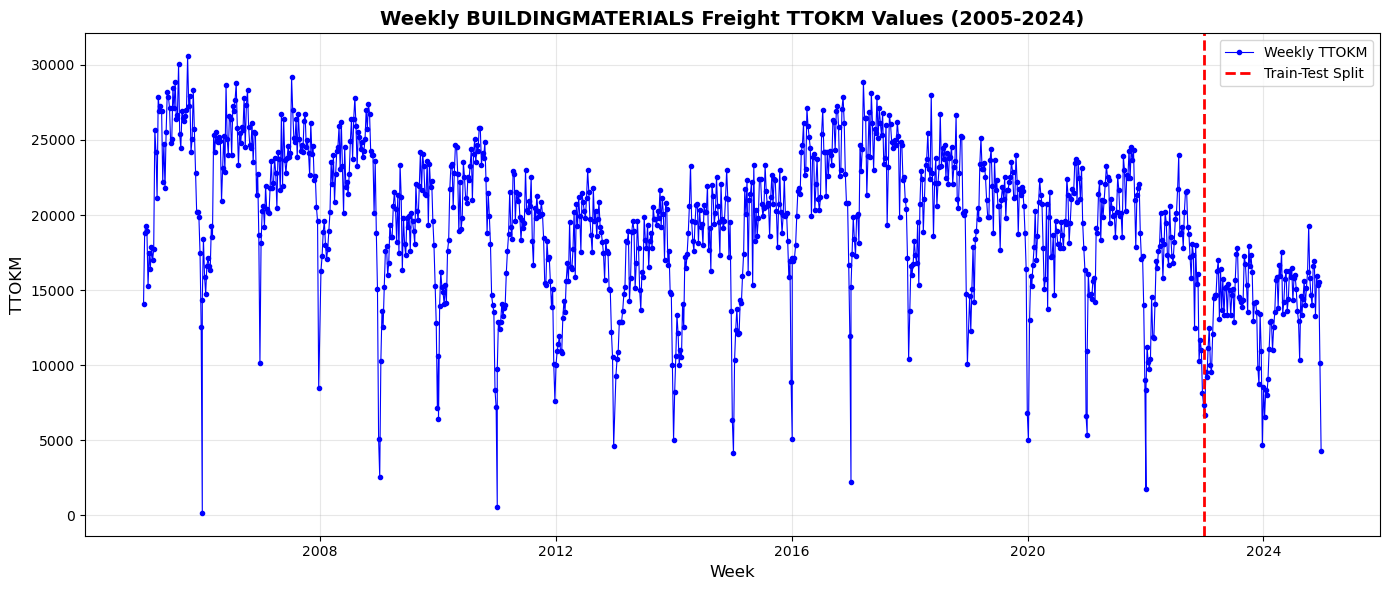

Complete dataset statistics:
count     1047.000000
mean     19382.413563
std       4952.587163
min        171.000000
25%      16361.500000
50%      19934.000000
75%      23009.000000
max      30576.000000
Name: TTOKM, dtype: float64


In [7]:
plt.figure(figsize=(14, 6))
plt.plot(weekly_data.index, weekly_data['TTOKM'], marker='o', linestyle='-', color='b', linewidth=0.8, markersize=3, label='Weekly TTOKM')
plt.axvline(x=last_train_date, color='r', linestyle='--', linewidth=2, label='Train-Test Split')
plt.title(f'Weekly {COMMODITY.upper()} Freight TTOKM Values (2005-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Week', fontsize=12)
plt.ylabel('TTOKM', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Complete dataset statistics:")
print(weekly_data['TTOKM'].describe())

### Calendar Week Distribution (Boxplot)

Visualize the distribution of TTOKM values for each calendar week to identify seasonal patterns and variability.

/var/folders/q0/7gd9v1qs2bx6jzy1q9mhg_bh0000gp/T/ipykernel_80500/1666393109.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


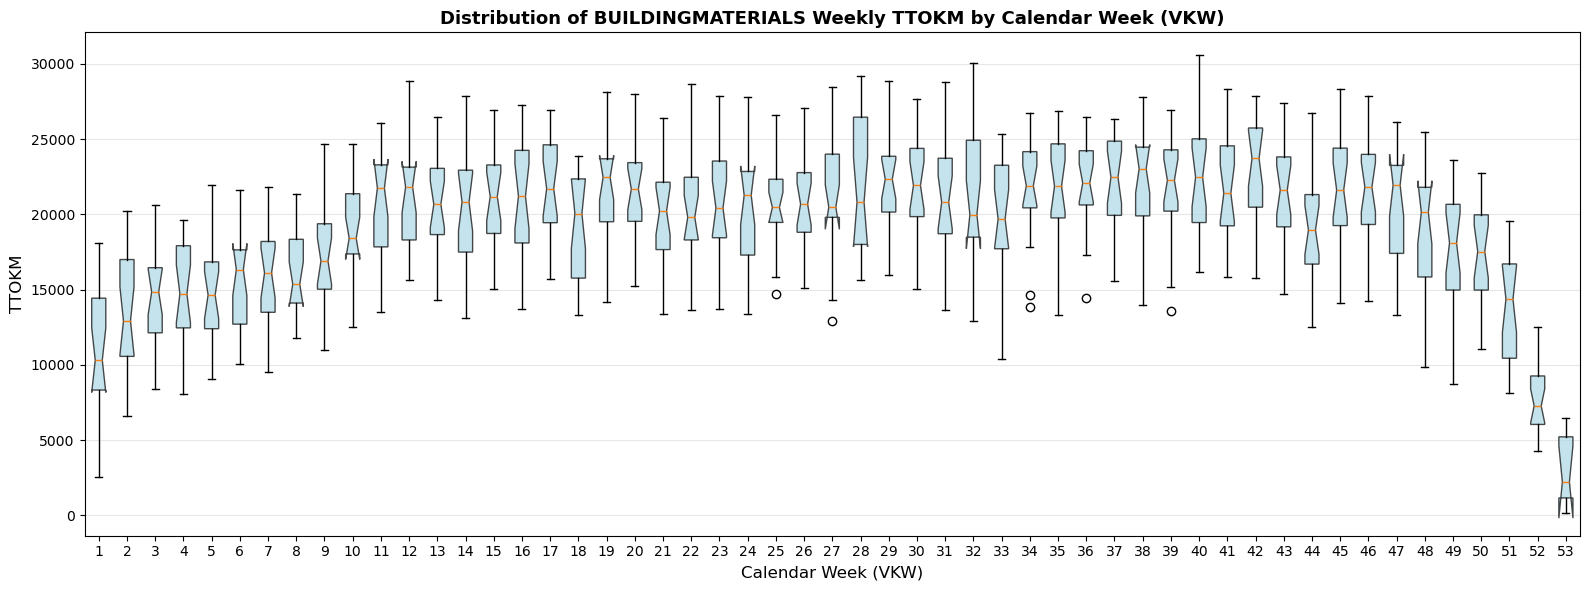


Summary Statistics by Calendar Week:
     count          mean   median          std      min      max
VKW                                                             
1       20  10877.750000  10314.5  4430.796945   2568.0  18108.0
2       20  13691.850000  12926.0  3770.114019   6581.0  20248.0
3       20  14572.450000  14852.0  3568.667604   8381.0  20622.0
4       20  14688.700000  14723.5  3315.485693   8038.0  19595.0
5       20  14736.050000  14643.5  3401.521231   9078.0  21935.0
6       20  15504.950000  16334.5  3473.878153  10034.0  21590.0
7       20  15879.300000  16108.5  3427.487742   9530.0  21795.0
8       20  16111.200000  15359.5  2907.167180  11810.0  21368.0
9       20  17361.550000  16901.0  3637.666451  11010.0  24647.0
10      20  19127.800000  18414.0  3255.067104  12514.0  24649.0
11      20  20701.650000  21754.0  3809.654167  13541.0  26105.0
12      20  21000.900000  21820.5  3432.468268  15617.0  28848.0
13      20  20540.500000  20667.5  3156.408994  1430

In [8]:
# Extract calendar week from VJAVKW for boxplot
weekly_data_temp = weekly_data.reset_index()
weekly_data_temp['VKW'] = weekly_data_temp['VJAVKW'].str[-2:].astype(int)

plt.figure(figsize=(16, 6))
bp = plt.boxplot(
    [weekly_data_temp[weekly_data_temp['VKW'] == week]['TTOKM'].values 
     for week in sorted(weekly_data_temp['VKW'].unique())],
    labels=sorted(weekly_data_temp['VKW'].unique()),
    patch_artist=True,
    notch=True
)

# Color the boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

plt.title(f'Distribution of {COMMODITY.upper()} Weekly TTOKM by Calendar Week (VKW)', fontsize=13, fontweight='bold')
plt.xlabel('Calendar Week (VKW)', fontsize=12)
plt.ylabel('TTOKM', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary statistics by calendar week
print(f"\nSummary Statistics by Calendar Week:")
week_stats = weekly_data_temp.groupby('VKW')['TTOKM'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(week_stats)

### Time Series Decomposition

Decompose the time series into trend, seasonality, and residual components using additive model.

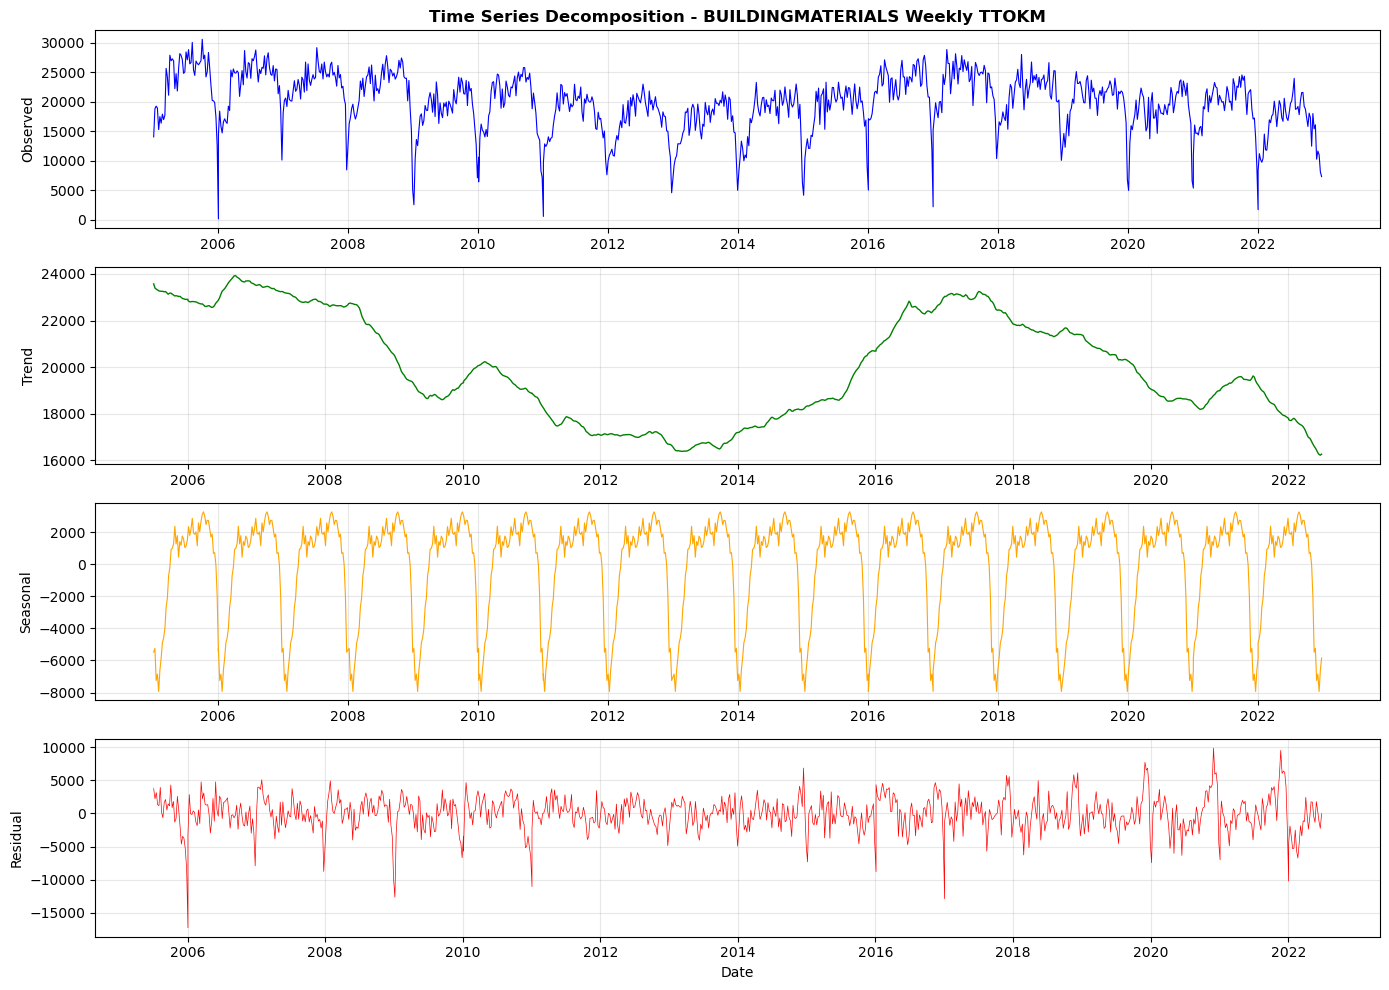

In [9]:
# Perform seasonal decomposition on training data
# Using a period of 52 weeks (1 year) for weekly decomposition
decompose_result = seasonal_decompose(data_train['TTOKM'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Original series
axes[0].plot(decompose_result.observed.index, decompose_result.observed, color='b', linewidth=0.8)
axes[0].set_ylabel('Observed', fontsize=10)
axes[0].set_title(f'Time Series Decomposition - {COMMODITY.upper()} Weekly TTOKM', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decompose_result.trend.index, decompose_result.trend, color='g', linewidth=1)
axes[1].set_ylabel('Trend', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Seasonality
axes[2].plot(decompose_result.seasonal.index, decompose_result.seasonal, color='orange', linewidth=0.8)
axes[2].set_ylabel('Seasonal', fontsize=10)
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(decompose_result.resid.index, decompose_result.resid, color='r', linewidth=0.5)
axes[3].set_ylabel('Residual', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Basic Statistics and Outlier Analysis

Analyze data distribution and identify potential outliers.

In [10]:
# Calculate statistics for training data
print(f"Training Data Statistics ({COMMODITY}):")
print(f"  Mean: {data_train['TTOKM'].mean():.2f}")
print(f"  Median: {data_train['TTOKM'].median():.2f}")
print(f"  Std Dev: {data_train['TTOKM'].std():.2f}")
print(f"  Min: {data_train['TTOKM'].min():.2f}")
print(f"  Max: {data_train['TTOKM'].max():.2f}")
print(f"  Q1: {data_train['TTOKM'].quantile(0.25):.2f}")
print(f"  Q3: {data_train['TTOKM'].quantile(0.75):.2f}")

# IQR for outlier detection
Q1 = data_train['TTOKM'].quantile(0.25)
Q3 = data_train['TTOKM'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_train[(data_train['TTOKM'] < lower_bound) | (data_train['TTOKM'] > upper_bound)]
print(f"\nOutliers detected (IQR method): {len(outliers)} weeks")
if len(outliers) > 0:
    print(f"Outlier range: {lower_bound:.2f} to {upper_bound:.2f}")

Training Data Statistics (buildingmaterials):
  Mean: 19997.68
  Median: 20380.00
  Std Dev: 4744.65
  Min: 171.00
  Max: 30576.00
  Q1: 17596.50
  Q3: 23360.00

Outliers detected (IQR method): 26 weeks
Outlier range: 8951.25 to 32005.25


## PROPHET Model

Use Facebook's PROPHET forecasting tool to predict weekly volumes.

In [11]:
# Prepare data for Prophet (requires 'ds' and 'y' columns) for weekly data  
prophet_df = data_train.reset_index()
prophet_df = prophet_df[['VJAVKW_DT', 'TTOKM']].rename(columns={'VJAVKW_DT': 'ds', 'TTOKM': 'y'})

print(f"Prophet training data shape: {prophet_df.shape}")
print(f"Date range: {prophet_df['ds'].min()} to {prophet_df['ds'].max()}")

Prophet training data shape: (943, 2)
Date range: 2005-01-03 00:00:00 to 2022-12-26 00:00:00


In [12]:
# Fit Prophet model
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.03,
    n_changepoints=5,
    interval_width=0.95
)

# Fit the model
print(f"Fitting Prophet model...")
m.fit(prophet_df)
print(f"Prophet model fitted successfully")

13:02:33 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet model...


13:02:33 - cmdstanpy - INFO - Chain [1] done processing
13:02:33 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
13:02:33 - cmdstanpy - INFO - Chain [1] start processing
13:02:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted successfully


In [13]:
# Generate forecast for the next 104 weeks (2 calendar years) after TRAIN_END    
future = m.make_future_dataframe(periods=FORECAST_HORIZON, freq='W-MON')
forecast = m.predict(future)

# Prepare comparison dataframe
prophet_forecast = pd.DataFrame({
    'ds': future['ds'],
    'yhat': forecast['yhat'],
    'yhat_lower': forecast['yhat_lower'],
    'yhat_upper': forecast['yhat_upper']
})

prophet_forecast = prophet_forecast.set_index('ds')

# Align actuals safely (avoid KeyError by reindexing; missing dates become NaN)
# Aggregate duplicate dates in weekly_data (sum) and align actuals safely
weekly_actuals = weekly_data['TTOKM'].groupby(level=0).sum()
prophet_forecast['actual'] = weekly_actuals.reindex(prophet_forecast.index)

print(f"Forecast generated for {FORECAST_HORIZON} weeks")
print(f"\nForecast tail (last 5 rows):")
print(prophet_forecast.tail())

Forecast generated for 104 weeks

Forecast tail (last 5 rows):
                    yhat    yhat_lower    yhat_upper   actual
ds                                                           
2024-11-25  15939.829502  10650.549199  21301.174932  15927.0
2024-12-02  14975.769334   9891.548883  20236.800841  15336.0
2024-12-09  12867.234781   7920.852852  17858.686552  15520.0
2024-12-16   9585.682883   4390.334424  14882.861882  10128.0
2024-12-23   6208.681786    960.195976  11477.450719   4271.0


In [14]:
# evaluate Prophet on initial weekly data (only where actual values are available, i.e. overlap between forecast and test period)
overlap_mask = ~prophet_forecast['actual'].isna()
test_mask = (prophet_forecast.index >= TEST_START) & (prophet_forecast.index <= TEST_END)
test_overlap = overlap_mask & test_mask 
prophet_eval = prophet_forecast[test_overlap]
print(f"\nEvaluation data points (overlap between forecast and test period): {prophet_eval.shape[0]} weeks")
print(f"\nEvaluation data (first 5 rows):")
print(prophet_eval.head())  
print(f"\nEvaluation data (last 5 rows):")
print(prophet_eval.tail())

# Calculate evaluation metrics for Prophet
mse_prophet = mean_squared_error(prophet_eval['actual'], prophet_eval['yhat'])
mae_prophet = mean_absolute_error(prophet_eval['actual'], prophet_eval['yhat'])
mape_prophet = mean_absolute_percentage_error(prophet_eval['actual'], prophet_eval['yhat'])
print(f"\nProphet Evaluation Metrics (on overlapping test period):")
print(f"  MSE: {mse_prophet:.2f}")
print(f"  MAE: {mae_prophet:.2f}")
print(f"  MAPE: {mape_prophet:.2%}")    




Evaluation data points (overlap between forecast and test period): 104 weeks

Evaluation data (first 5 rows):
                    yhat   yhat_lower    yhat_upper   actual
ds                                                          
2023-01-02   6416.790022  2076.769663  11192.934014   6690.0
2023-01-09   7922.426367  3632.057888  12399.885562   9582.0
2023-01-16  10585.508010  5812.963556  15232.966969   9219.0
2023-01-23  12517.742629  8057.097581  17721.575771  11153.0
2023-01-30  12806.273373  8083.321739  17297.580231  12505.0

Evaluation data (last 5 rows):
                    yhat    yhat_lower    yhat_upper   actual
ds                                                           
2024-11-25  15939.829502  10650.549199  21301.174932  15927.0
2024-12-02  14975.769334   9891.548883  20236.800841  15336.0
2024-12-09  12867.234781   7920.852852  17858.686552  15520.0
2024-12-16   9585.682883   4390.334424  14882.861882  10128.0
2024-12-23   6208.681786    960.195976  11477.450719   427

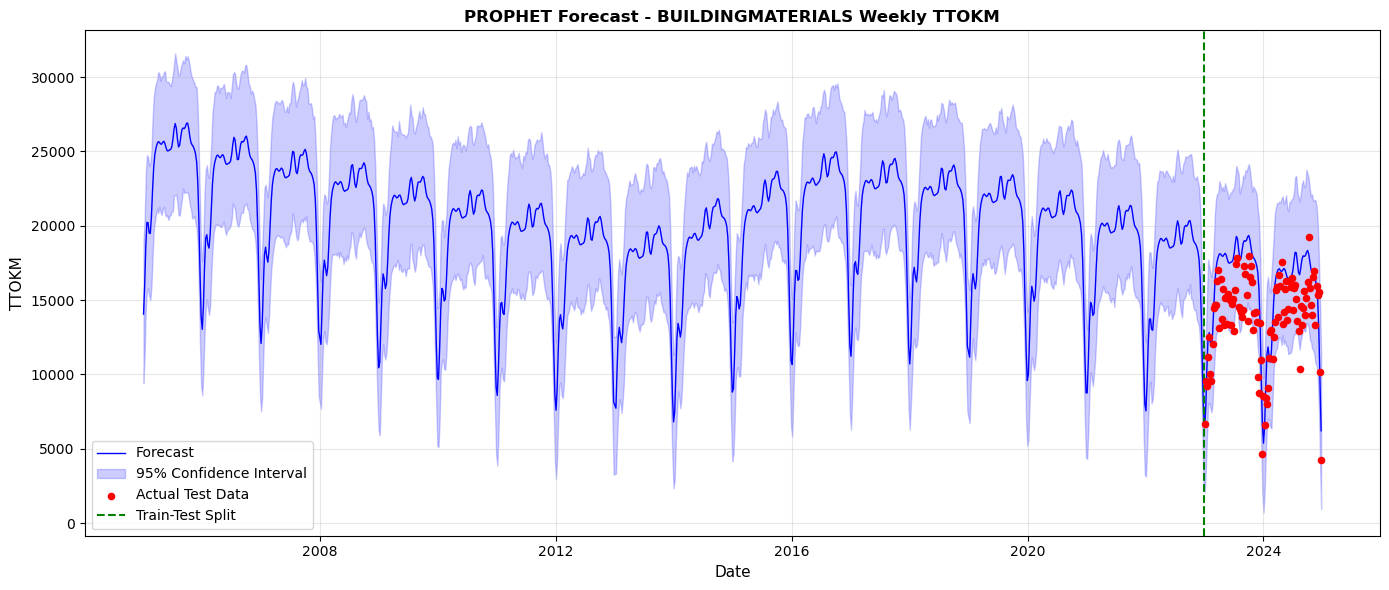

In [15]:
# Plot Prophet forecast
plt.figure(figsize=(14, 6))
plt.plot(prophet_forecast[prophet_forecast.index <= TEST_END].index, 
         prophet_forecast[prophet_forecast.index <= TEST_END]['yhat'], 
         label='Forecast', color='blue', linewidth=1)
plt.fill_between(prophet_forecast[prophet_forecast.index <= TEST_END].index, 
                 prophet_forecast[prophet_forecast.index <= TEST_END]['yhat_lower'], 
                 prophet_forecast[prophet_forecast.index <= TEST_END]['yhat_upper'], 
                 color='blue', alpha=0.2, label='95% Confidence Interval')
plt.scatter(prophet_forecast[test_overlap].index, 
            prophet_forecast[test_overlap]['actual'], 
            color='red', s=20, label='Actual Test Data', zorder=5)
plt.axvline(x=last_train_date, color='green', linestyle='--', linewidth=1.5, label='Train-Test Split')
plt.title(f'PROPHET Forecast - {COMMODITY.upper()} Weekly TTOKM', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('TTOKM', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

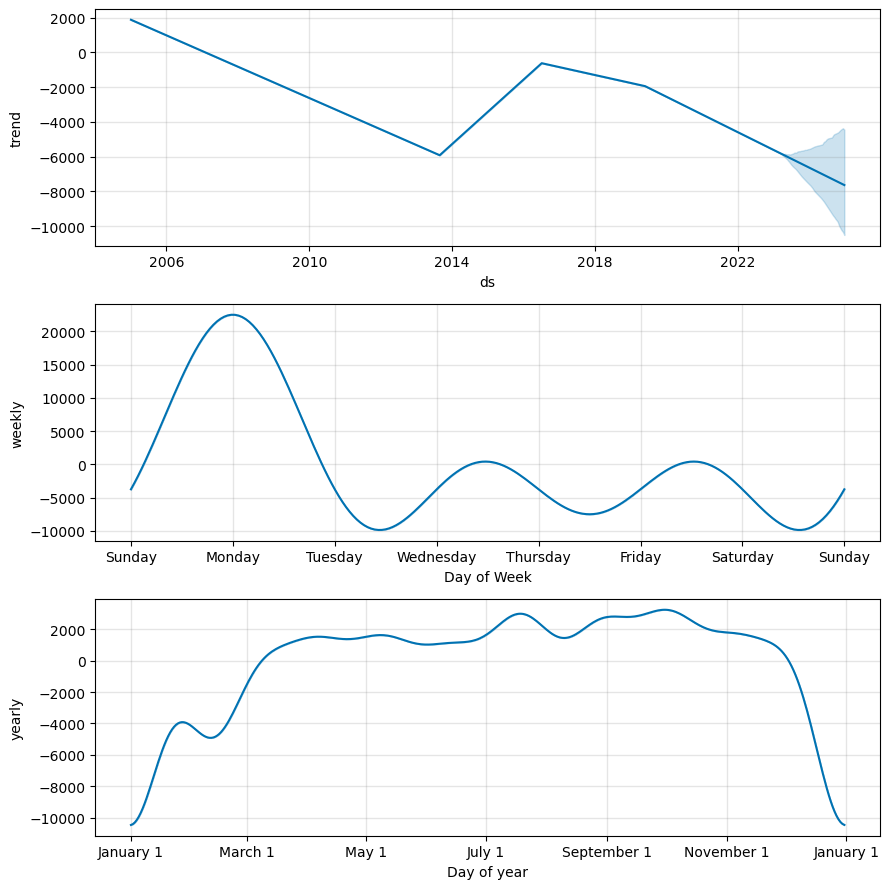

In [16]:
# Plot Prophet components
fig = m.plot_components(forecast)
plt.tight_layout()
plt.show()

## SARIMAX Model

Use SARIMAX model with auto_arima to automatically find optimal parameters.

In [17]:
# Auto ARIMA to find best parameters
print("Running auto_arima to find optimal SARIMAX parameters...")
print("Using stepwise selection to optimize search speed...\n")

# Monkeypatch sklearn.check_array to ignore legacy 'force_all_finite' kwarg if present
if not getattr(sklearn.utils.validation.check_array, "_patched_for_force_all_finite", False):
    _orig_check_array = sklearn.utils.validation.check_array
    def _check_array(*args, **kwargs):
        kwargs.pop('force_all_finite', None)
        return _orig_check_array(*args, **kwargs)
    _check_array._patched_for_force_all_finite = True
    sklearn.utils.validation.check_array = _check_array

# Run auto_arima with optimized parameters for faster convergence
# Using smaller search space and stepwise selection to reduce computation time
auto_model = pm.auto_arima(
    data_train['TTOKM'], 
    seasonal=True, 
    m=52,  # 52 weeks in a year
    trace=False, 
    suppress_warnings=True,
    stepwise=True,  # Explicit stepwise for efficiency
    max_p=3,  # Reduced from 5 for faster search
    max_q=3,  # Reduced from 5 for faster search
    max_P=1,  # Reduced from 2 for faster search
    max_Q=1,  # Reduced from 2 for faster search
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0
)

print(f"Optimal order: {auto_model.order}")
print(f"Optimal seasonal order: {auto_model.seasonal_order}")
print(f"✓ Auto-ARIMA completed successfully")

Running auto_arima to find optimal SARIMAX parameters...
Using stepwise selection to optimize search speed...

Optimal order: (1, 1, 2)
Optimal seasonal order: (1, 0, 1, 52)
✓ Auto-ARIMA completed successfully


In [18]:
# Fit SARIMA model with auto_arima parameters
sarima_model = SARIMAX(
    data_train['TTOKM'],
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Fitting SARIMA model...")
sarima_result = sarima_model.fit(disp=False)
print("SARIMA model fitted successfully\n")

print(sarima_result.summary())

Fitting SARIMA model...


/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA model fitted successfully

                                      SARIMAX Results                                       
Dep. Variable:                                TTOKM   No. Observations:                  943
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 52)   Log Likelihood               -8131.422
Date:                              Sun, 07 Jun 2026   AIC                          16274.844
Time:                                      13:05:29   BIC                          16303.571
Sample:                                           0   HQIC                         16285.826
                                              - 943                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8343      0.061     13.598      0.000       0.7

In [19]:
# Generate SARIMAX forecast
print(f"Generating SARIMAX forecast for {FORECAST_HORIZON} weeks...")
forecast_sarimax = sarima_result.get_forecast(steps=FORECAST_HORIZON)
forecast_sarimax_values = forecast_sarimax.predicted_mean
forecast_sarimax_ci = forecast_sarimax.conf_int()

# Get the actual weekly dates from the full dataset to ensure alignment
all_weekly_dates = weekly_data.index
last_train_date_idx = all_weekly_dates.get_loc(last_train_date)

# Use the actual weekly dates from the dataset for forecast alignment
# This ensures the forecast dates match the test data dates
forecast_dates = all_weekly_dates[last_train_date_idx + 1:last_train_date_idx + 1 + FORECAST_HORIZON]

# Create forecast dataframe with proper date alignment
forecast_sarimax_df = pd.DataFrame({
    'yhat': forecast_sarimax_values.values[:len(forecast_dates)],
    'lower': forecast_sarimax_ci.iloc[:len(forecast_dates), 0].values,
    'upper': forecast_sarimax_ci.iloc[:len(forecast_dates), 1].values
}, index=forecast_dates)

print(f"SARIMAX forecast generated")
print(f"Forecast dates: {forecast_sarimax_df.index.min()} to {forecast_sarimax_df.index.max()}")
print(f"\nForecast tail (last 5 rows):")
print(forecast_sarimax_df.tail())

Generating SARIMAX forecast for 104 weeks...
SARIMAX forecast generated
Forecast dates: 2023-01-02 00:00:00 to 2024-12-23 00:00:00

Forecast tail (last 5 rows):
                    yhat        lower         upper
VJAVKW_DT                                          
2024-11-25  12707.403298  3461.063760  21953.742835
2024-12-02  12883.171884  3615.484813  22150.858955
2024-12-09  11336.939540  2047.955298  20625.923781
2024-12-16   9823.531390   513.299781  19133.763000
2024-12-23   9170.611908  -160.817788  18502.041603


/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [20]:
# Evaluate SARIMAX on test data
sarimax_test_data = weekly_data[(weekly_data.index >= TEST_START) & (weekly_data.index <= TEST_END)]

# Debug: Print date ranges
print(f"Test data date range: {sarimax_test_data.index.min()} to {sarimax_test_data.index.max()}")
print(f"Forecast date range: {forecast_sarimax_df.index.min()} to {forecast_sarimax_df.index.max()}")
print(f"Forecast shape: {forecast_sarimax_df.shape}, Test data shape: {sarimax_test_data.shape}")

sarimax_forecast_aligned = forecast_sarimax_df[forecast_sarimax_df.index.isin(sarimax_test_data.index)]
print(f"Overlapping dates: {len(sarimax_forecast_aligned)}")

if len(sarimax_forecast_aligned) > 0 and len(sarimax_test_data) > 0:
    # Align indices properly for evaluation
    actual_overlap = sarimax_test_data.loc[sarimax_forecast_aligned.index, 'TTOKM']
    pred_overlap = sarimax_forecast_aligned['yhat']
    
    actual_vals = actual_overlap.values
    pred_vals = pred_overlap.values
    
    mse_sarimax = ((actual_vals - pred_vals) ** 2).mean()
    rmse_sarimax = np.sqrt(mse_sarimax)
    mae_sarimax = np.abs(actual_vals - pred_vals).mean()
    mape_sarimax = mean_absolute_percentage_error(actual_vals, pred_vals)
    
    print(f"\nSARIMAX Model Performance (Test Period):")
    print(f"  RMSE: {rmse_sarimax:.2f}")
    print(f"  MAE: {mae_sarimax:.2f}")
    print(f"  MAPE: {mape_sarimax:.4f}")
else:
    print("\n⚠ No overlapping test data available for SARIMAX evaluation")
    print("This typically means the forecast dates don't align with test period (2023-2024)")

Test data date range: 2023-01-02 00:00:00 to 2024-12-23 00:00:00
Forecast date range: 2023-01-02 00:00:00 to 2024-12-23 00:00:00
Forecast shape: (104, 3), Test data shape: (104, 2)
Overlapping dates: 104

SARIMAX Model Performance (Test Period):
  RMSE: 2454.82
  MAE: 2040.76
  MAPE: 0.1794


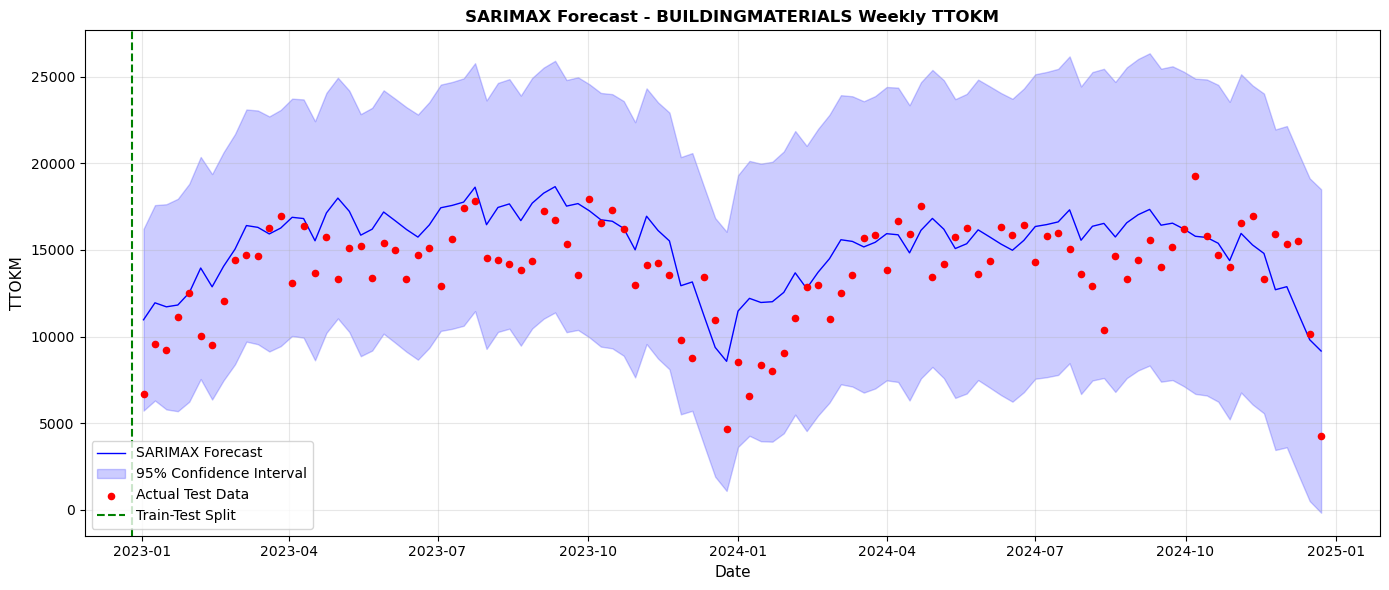

In [21]:
# Plot SARIMAX forecast
plt.figure(figsize=(14, 6))
plt.plot(forecast_sarimax_df.index[forecast_sarimax_df.index <= TEST_END], 
         forecast_sarimax_df[forecast_sarimax_df.index <= TEST_END]['yhat'], 
         label='SARIMAX Forecast', color='blue', linewidth=1)
plt.fill_between(forecast_sarimax_df[forecast_sarimax_df.index <= TEST_END].index, 
                 forecast_sarimax_df[forecast_sarimax_df.index <= TEST_END]['lower'], 
                 forecast_sarimax_df[forecast_sarimax_df.index <= TEST_END]['upper'], 
                 color='blue', alpha=0.2, label='95% Confidence Interval')
plt.scatter(sarimax_test_data.index, sarimax_test_data['TTOKM'], 
            color='red', s=20, label='Actual Test Data', zorder=5)
plt.axvline(x=last_train_date, color='green', linestyle='--', linewidth=1.5, label='Train-Test Split')
plt.title(f'SARIMAX Forecast - {COMMODITY.upper()} Weekly TTOKM', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('TTOKM', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LSTM Model

Create a Long Short-Term Memory neural network model for forecasting.

In [22]:
# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
data_train_scaled = scaler.fit_transform(data_train[['TTOKM']])

print(f"Data scaled to range [0, 1]")
print(f"Original range: {data_train['TTOKM'].min():.2f} to {data_train['TTOKM'].max():.2f}")
print(f"Scaled range: {data_train_scaled.min():.4f} to {data_train_scaled.max():.4f}")

Data scaled to range [0, 1]
Original range: 171.00 to 30576.00
Scaled range: 0.0000 to 1.0000


In [23]:
# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Create sequences
X, y = create_sequences(data_train_scaled, SEQ_LENGTH)
X = X.reshape(X.shape[0], X.shape[1], 1)  # Reshape for LSTM input (samples, timesteps, features)

# Train-test split (90-10)
split = int(len(X) * 0.9)
X_train_lstm, X_test_lstm = X[:split], X[split:]
y_train_lstm, y_test_lstm = y[:split], y[split:]

print(f"LSTM training data shape: {X_train_lstm.shape}")
print(f"LSTM test data shape: {X_test_lstm.shape}")
print(f"Sequence length: {SEQ_LENGTH} weeks")

LSTM training data shape: (801, 52, 1)
LSTM test data shape: (90, 52, 1)
Sequence length: 52 weeks


In [24]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    LSTM(50, return_sequences=False),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compile model
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("LSTM Model Architecture:")
lstm_model.summary()

LSTM Model Architecture:


/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 52, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train LSTM model
print("Training LSTM model...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm, 
    validation_data=(X_test_lstm, y_test_lstm), 
    epochs=20, 
    batch_size=16,
    verbose=1
)

print("\nLSTM model training completed")

Training LSTM model...
Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0731 - mae: 0.1868 - val_loss: 0.0187 - val_mae: 0.1047
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0193 - mae: 0.1041 - val_loss: 0.0177 - val_mae: 0.0946
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0171 - mae: 0.0931 - val_loss: 0.0174 - val_mae: 0.0930
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0163 - mae: 0.0916 - val_loss: 0.0295 - val_mae: 0.1268
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0161 - mae: 0.0892 - val_loss: 0.0136 - val_mae: 0.0831
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0137 - mae: 0.0816 - val_loss: 0.0124 - val_mae: 0.0789
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0123 - mae: 0.0777 - val_loss: 0.0141 - val_mae: 0.0850
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0123 - mae: 0.0777 - val_loss: 0.0095 - val_mae: 0.0701
Epoch 9/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 

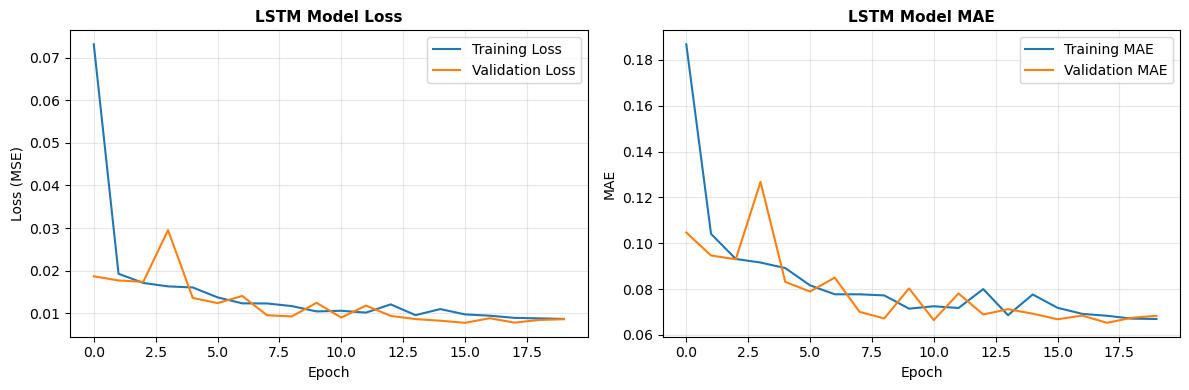

In [26]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=1.5)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=1.5)
plt.title('LSTM Model Loss', fontsize=11, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=1.5)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=1.5)
plt.title('LSTM Model MAE', fontsize=11, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Make predictions on test set
y_pred_lstm = lstm_model.predict(X_test_lstm)

# Inverse scale predictions
y_pred_lstm_rescaled = scaler.inverse_transform(y_pred_lstm.reshape(-1, 1))
y_test_lstm_rescaled = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

print(f"LSTM predictions generated")
print(f"Predictions shape: {y_pred_lstm_rescaled.shape}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
LSTM predictions generated
Predictions shape: (90, 1)


In [28]:
# Evaluate LSTM model
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_rescaled, y_pred_lstm_rescaled))
mae_lstm = mean_absolute_error(y_test_lstm_rescaled, y_pred_lstm_rescaled)
mape_lstm = mean_absolute_percentage_error(y_test_lstm_rescaled, y_pred_lstm_rescaled)

print(f"LSTM Model Performance:")
print(f"  RMSE: {rmse_lstm:.2f}")
print(f"  MAE: {mae_lstm:.2f}")
print(f"  MAPE: {mape_lstm:.4f}")

LSTM Model Performance:
  RMSE: 2821.20
  MAE: 2077.77
  MAPE: 0.2098


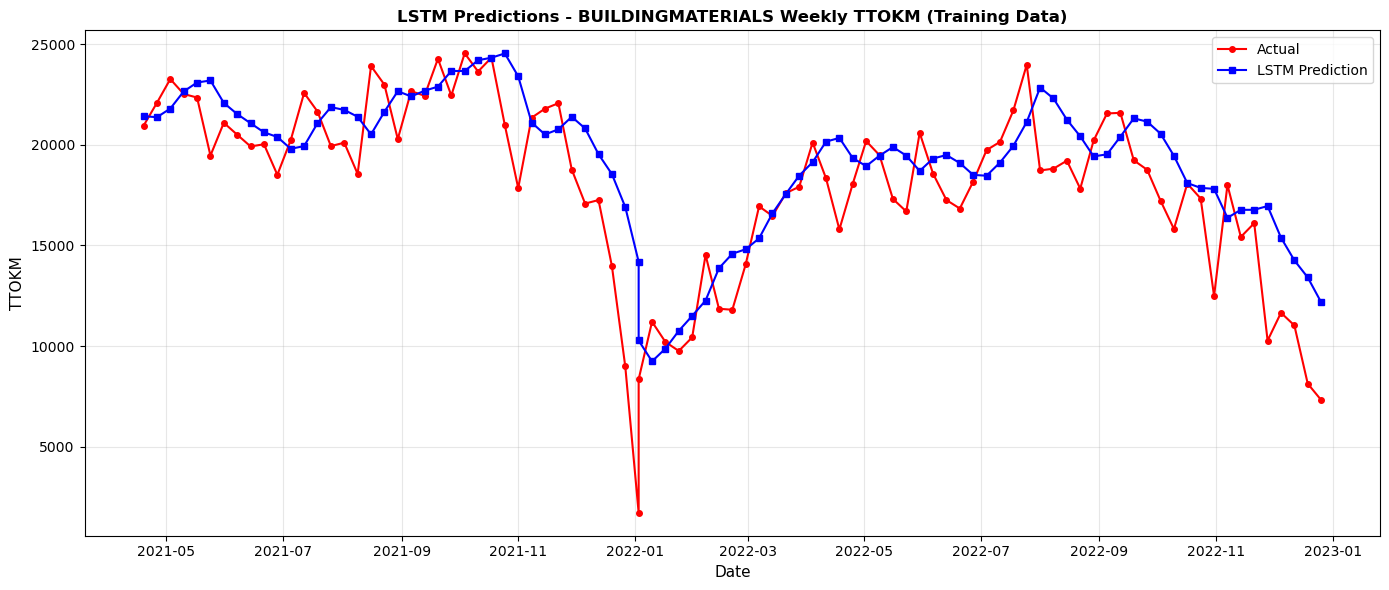

In [29]:
# Plot LSTM predictions
lstm_test_dates = data_train.index[-(len(y_test_lstm)):]
lstm_pred_dates = lstm_test_dates[SEQ_LENGTH:]

plt.figure(figsize=(14, 6))
lstm_pred_dates = lstm_test_dates
plt.plot(lstm_pred_dates, y_test_lstm_rescaled.ravel(), label='Actual', color='red', linewidth=1.5, marker='o', markersize=4)
plt.plot(lstm_pred_dates, y_pred_lstm_rescaled, label='LSTM Prediction', color='blue', linewidth=1.5, marker='s', markersize=4)
plt.title(f'LSTM Predictions - {COMMODITY.upper()} Weekly TTOKM (Training Data)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('TTOKM', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ETS (Exponential Smoothing) Model

Use Holt-Winters exponential smoothing for forecasting.

In [30]:
# Fit Holt-Winters model
# Using additive model with 52-week seasonality (yearly pattern)
print("Fitting Exponential Smoothing (Holt-Winters) model...")

hw_model = ExponentialSmoothing(
    data_train['TTOKM'], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=52  # 52 weeks per year
)

hw_result = hw_model.fit(optimized=True)
print("Exponential Smoothing model fitted successfully")

print(f"\nModel Summary:")
print(hw_result.summary())

Fitting Exponential Smoothing (Holt-Winters) model...
Exponential Smoothing model fitted successfully

Model Summary:
                       ExponentialSmoothing Model Results                       
Dep. Variable:                    TTOKM   No. Observations:                  943
Model:             ExponentialSmoothing   SSE                     5660492015.853
Optimized:                         True   AIC                          14830.071
Trend:                         Additive   BIC                          15101.619
Seasonal:                      Additive   AICC                         14837.813
Seasonal Periods:                    52   Date:                 Sun, 07 Jun 2026
Box-Cox:                          False   Time:                         13:05:43
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
-----------------------------------------------------------------------

/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [31]:
# Generate ETS forecast
print(f"Generating ETS forecast for {FORECAST_HORIZON} weeks...")
ets_forecast = hw_result.forecast(steps=FORECAST_HORIZON)

# Create forecast index
ets_forecast_index = pd.date_range(start=last_train_date + pd.Timedelta(weeks=1), periods=FORECAST_HORIZON, freq='W-MON')
ets_forecast_df = pd.DataFrame({
    'yhat': ets_forecast.values
}, index=ets_forecast_index)

print(f"ETS forecast generated")
print(f"\nForecast tail (last 5 rows):")
print(ets_forecast_df.tail())

Generating ETS forecast for 104 weeks...
ETS forecast generated

Forecast tail (last 5 rows):
                    yhat
2024-11-25  13238.235546
2024-12-02  12952.906584
2024-12-09   8872.581047
2024-12-16   5880.302401
2024-12-23   3463.492663


/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [32]:
# Evaluate ETS on test data
ets_test_data = weekly_data[(weekly_data.index >= TEST_START) & (weekly_data.index <= TEST_END)]
ets_forecast_aligned = ets_forecast_df[ets_forecast_df.index.isin(ets_test_data.index)]

if len(ets_forecast_aligned) > 0 and len(ets_test_data) > 0:
    actual_overlap = ets_test_data['TTOKM']
    pred_overlap = ets_forecast_aligned['yhat']
    
    mse_ets = ((actual_overlap - pred_overlap) ** 2).mean()
    rmse_ets = np.sqrt(mse_ets)
    mae_ets = (actual_overlap - pred_overlap).abs().mean()
    mape_ets = mean_absolute_percentage_error(actual_overlap, pred_overlap)
    
    print(f"ETS Model Performance (Test Period):")
    print(f"  RMSE: {rmse_ets:.2f}")
    print(f"  MAE: {mae_ets:.2f}")
    print(f"  MAPE: {mape_ets:.4f}")
else:
    print("No overlapping test data available for ETS evaluation")

ETS Model Performance (Test Period):
  RMSE: 4063.53
  MAE: 3646.12
  MAPE: 0.2783


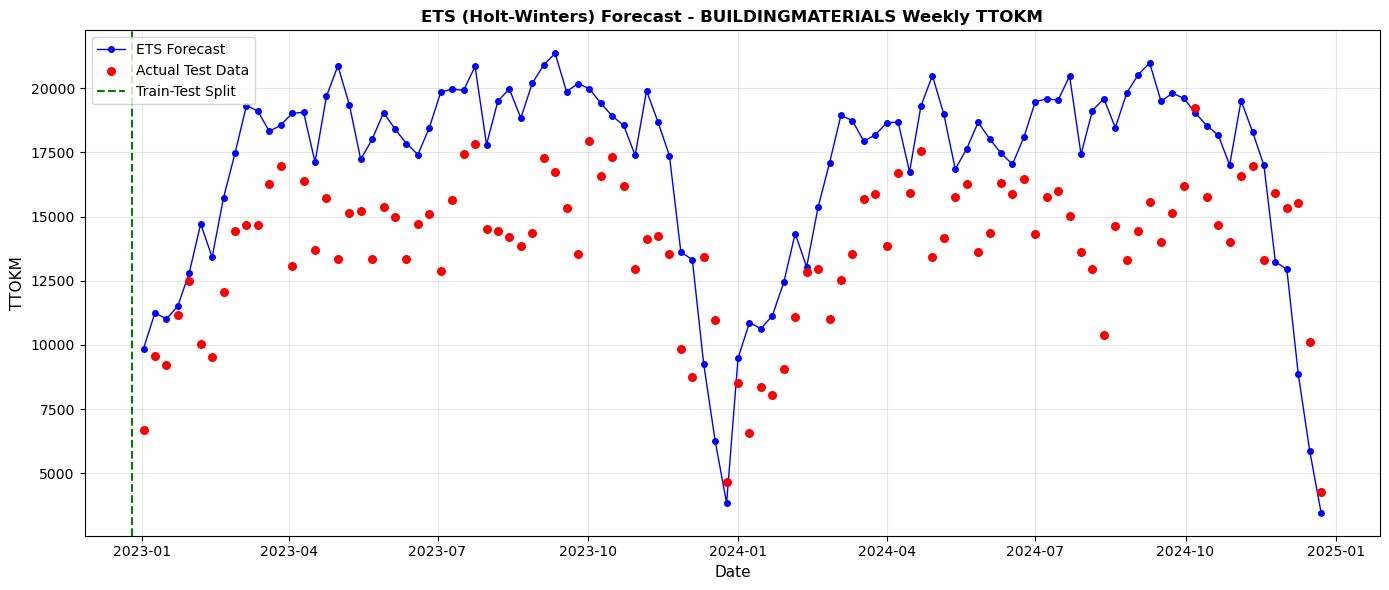

In [33]:
# Plot ETS forecast
plt.figure(figsize=(14, 6))
plt.plot(ets_forecast_df.index[ets_forecast_df.index <= TEST_END], 
         ets_forecast_df[ets_forecast_df.index <= TEST_END]['yhat'], 
         label='ETS Forecast', color='blue', linewidth=1, marker='o', markersize=4)
plt.scatter(ets_test_data.index, ets_test_data['TTOKM'], 
            color='red', s=30, label='Actual Test Data', zorder=5)
plt.axvline(x=last_train_date, color='green', linestyle='--', linewidth=1.5, label='Train-Test Split')
plt.title(f'ETS (Holt-Winters) Forecast - {COMMODITY.upper()} Weekly TTOKM', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('TTOKM', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model Comparison and Results

Compare all four forecasting models and visualize their performance.

### Performance Metrics Summary

Compare RMSE, MAE, and MAPE across all four models.

In [34]:
# Create a comprehensive metrics comparison
metrics_data = {
    'Model': ['PROPHET', 'SARIMAX', 'LSTM', 'ETS'],
    'RMSE': [rmse_prophet if 'rmse_prophet' in locals() else np.nan, 
             rmse_sarimax if 'rmse_sarimax' in locals() else np.nan,
             rmse_lstm,
             rmse_ets if 'rmse_ets' in locals() else np.nan],
    'MAE': [mae_prophet if 'mae_prophet' in locals() else np.nan,
            mae_sarimax if 'mae_sarimax' in locals() else np.nan,
            mae_lstm,
            mae_ets if 'mae_ets' in locals() else np.nan],
    'MAPE': [mape_prophet if 'mape_prophet' in locals() else np.nan,
             mape_sarimax if 'mape_sarimax' in locals() else np.nan,
             mape_lstm,
             mape_ets if 'mape_ets' in locals() else np.nan]
}

metrics_df = pd.DataFrame(metrics_data)
print("\n" + "="*60)
print(f"MODEL PERFORMANCE COMPARISON - {COMMODITY.upper()}")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)


MODEL PERFORMANCE COMPARISON - BUILDINGMATERIALS
  Model        RMSE         MAE     MAPE
PROPHET         NaN 2387.429191 0.187189
SARIMAX 2454.819240 2040.762388 0.179414
   LSTM 2821.196960 2077.772613 0.209831
    ETS 4063.533615 3646.116637 0.278339


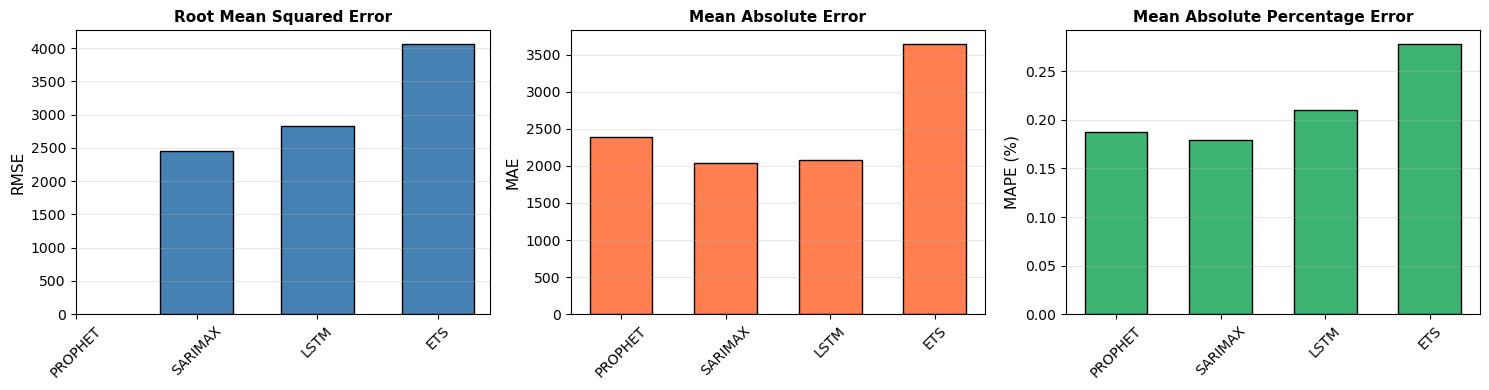

In [35]:
# Visualize metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = metrics_df['Model']
x = np.arange(len(models))
width = 0.6

# RMSE comparison
axes[0].bar(x, metrics_df['RMSE'], width=width, color='steelblue', edgecolor='black')
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('Root Mean Squared Error', fontsize=11, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[1].bar(x, metrics_df['MAE'], width=width, color='coral', edgecolor='black')
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('Mean Absolute Error', fontsize=11, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# MAPE comparison
axes[2].bar(x, metrics_df['MAPE'], width=width, color='mediumseagreen', edgecolor='black')
axes[2].set_ylabel('MAPE (%)', fontsize=11)
axes[2].set_title('Mean Absolute Percentage Error', fontsize=11, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Combined Forecast Visualization

Overlay all four model forecasts for visual comparison.

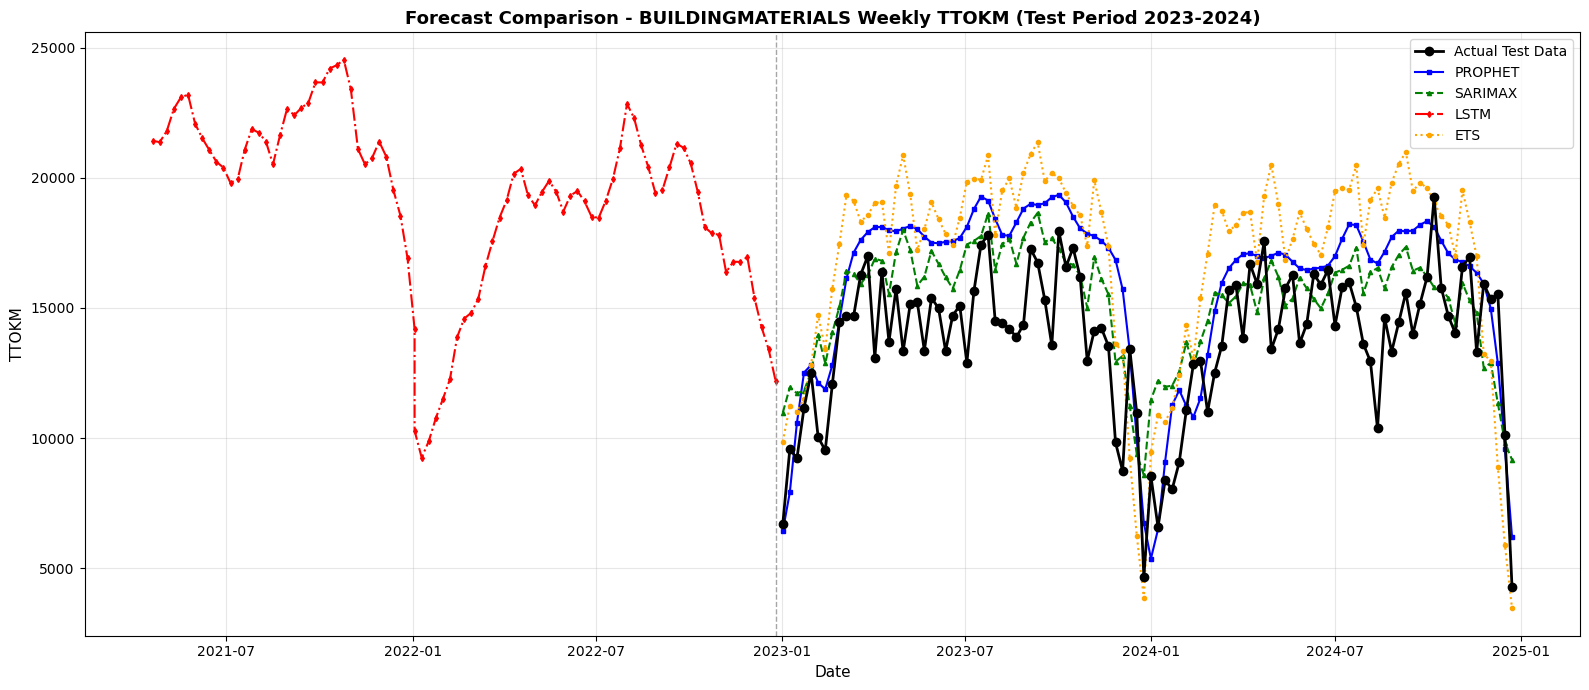

In [36]:
# Plot all forecasts together
plt.figure(figsize=(16, 7))

# Plot actual test data
test_data_plot = weekly_data[(weekly_data.index >= TEST_START) & (weekly_data.index <= TEST_END)]
plt.plot(test_data_plot.index, test_data_plot['TTOKM'], 
         color='black', marker='o', markersize=6, linewidth=2, label='Actual Test Data', zorder=10)

# Plot Prophet forecast
prophet_test = prophet_forecast[(prophet_forecast.index >= TEST_START) & (prophet_forecast.index <= TEST_END)]
plt.plot(prophet_test.index, prophet_test['yhat'], 
         color='blue', linewidth=1.5, label='PROPHET', linestyle='-', marker='s', markersize=3)

# Plot SARIMAX forecast
sarimax_test = forecast_sarimax_df[(forecast_sarimax_df.index >= TEST_START) & (forecast_sarimax_df.index <= TEST_END)]
plt.plot(sarimax_test.index, sarimax_test['yhat'], 
         color='green', linewidth=1.5, label='SARIMAX', linestyle='--', marker='^', markersize=3)

# Plot LSTM forecast (for dates that fall in test period)
plt.plot(lstm_pred_dates, y_pred_lstm_rescaled, 
         color='red', linewidth=1.5, label='LSTM', linestyle='-.', marker='d', markersize=3)

# Plot ETS forecast
ets_test = ets_forecast_df[(ets_forecast_df.index >= TEST_START) & (ets_forecast_df.index <= TEST_END)]
plt.plot(ets_test.index, ets_test['yhat'], 
         color='orange', linewidth=1.5, label='ETS', linestyle=':', marker='o', markersize=3)

plt.axvline(x=last_train_date, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.title(f'Forecast Comparison - {COMMODITY.upper()} Weekly TTOKM (Test Period 2023-2024)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('TTOKM', fontsize=11)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 104-Week Future Forecast

Visualize the 104-week ahead forecasts from all models for planning purposes.

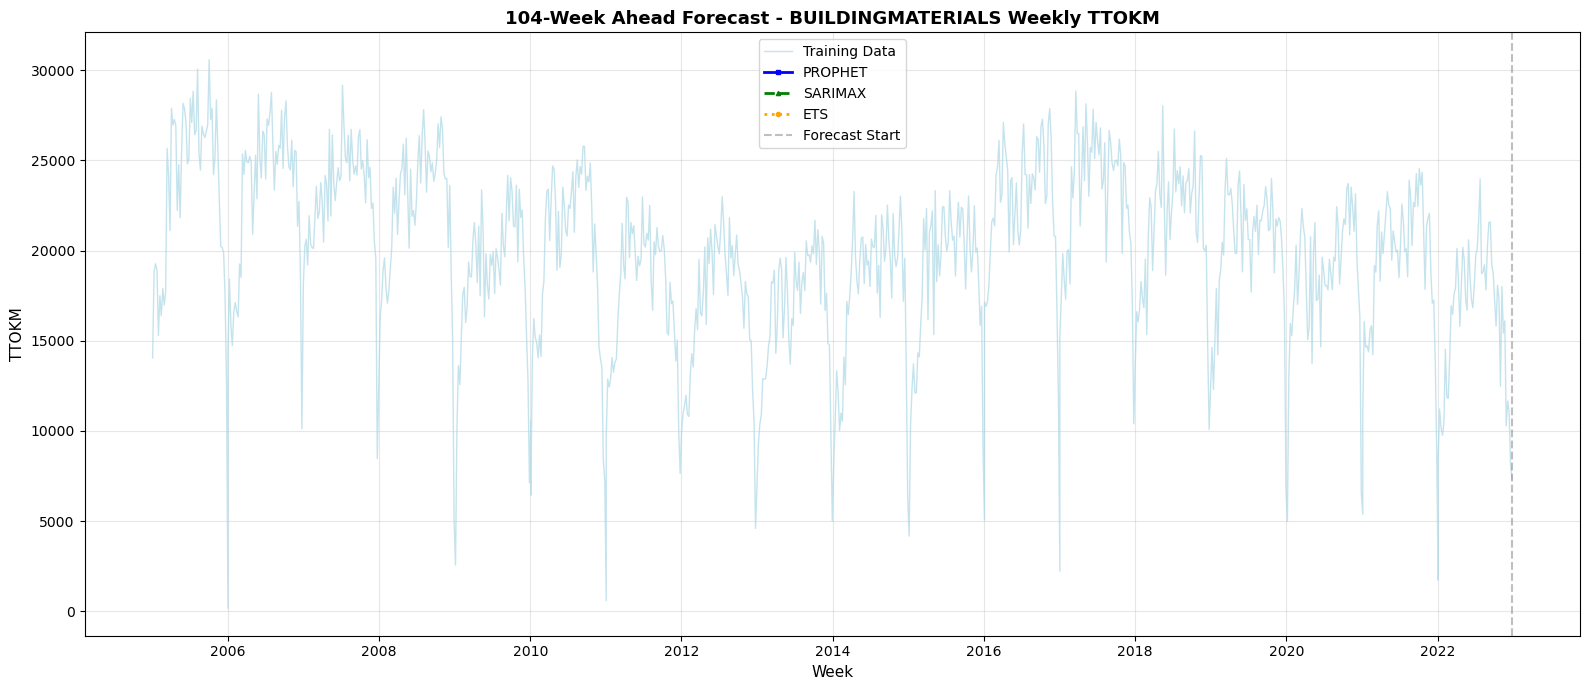


Forecast period: 2023-01-02 to 2024-12-30
Total weeks: 104


In [37]:
# Prepare future forecast data
future_start = last_train_date + pd.Timedelta(weeks=1)
future_end = future_start + pd.Timedelta(weeks=FORECAST_HORIZON)

plt.figure(figsize=(16, 7))

# Plot training data (for context)
plt.plot(data_train.index, data_train['TTOKM'], 
         color='lightblue', linewidth=1, label='Training Data', alpha=0.7)

# Plot future forecasts
prophet_future = prophet_forecast[(prophet_forecast.index > TEST_END) & (prophet_forecast.index <= future_end)]
plt.plot(prophet_future.index, prophet_future['yhat'], 
         color='blue', linewidth=2, label='PROPHET', linestyle='-', marker='s', markersize=3)

sarimax_future = forecast_sarimax_df[(forecast_sarimax_df.index > TEST_END) & (forecast_sarimax_df.index <= future_end)]
plt.plot(sarimax_future.index, sarimax_future['yhat'], 
         color='green', linewidth=2, label='SARIMAX', linestyle='--', marker='^', markersize=3)

ets_future = ets_forecast_df[(ets_forecast_df.index > TEST_END) & (ets_forecast_df.index <= future_end)]
plt.plot(ets_future.index, ets_future['yhat'], 
         color='orange', linewidth=2, label='ETS', linestyle=':', marker='o', markersize=3)

plt.axvline(x=last_train_date, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='Forecast Start')
plt.title(f'104-Week Ahead Forecast - {COMMODITY.upper()} Weekly TTOKM', 
          fontsize=13, fontweight='bold')
plt.xlabel('Week', fontsize=11)
plt.ylabel('TTOKM', fontsize=11)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForecast period: {future_start.date()} to {future_end.date()}")
print(f"Total weeks: {(future_end - future_start).days // 7}")

## Summary and Recommendations

### Key Findings

Based on the analysis of wood rail freight volumes using four different forecasting models:

1. **Best Performing Model**: Review the metrics table above to identify which model has the lowest RMSE, MAE, and MAPE.

2. **Model Characteristics**:
   - **PROPHET**: Good at capturing trend changes and seasonal patterns, provides confidence intervals
   - **SARIMAX**: Captures ARIMA dependencies, particularly effective for stationary series
   - **LSTM**: Deep learning approach, can capture complex non-linear patterns
   - **ETS**: Simple exponential smoothing, effective for stable seasonal patterns

3. **Forecast Horizon**: All models provide 104-week forecasts (approximately 2 calendar years)

### How to Update with New Data

When data for 2025 and Q1 2026 becomes available:

1. Save the new data to `/Users/Hans/Documents/EMBA/MasterThesis/Data/wood_2005_2024_update.csv`
2. Update the `DATA_FILE` variable to reflect the new file name
3. Adjust `TRAIN_END` and `TEST_END` date parameters
4. Re-run the entire notebook from top to bottom (Ctrl+Shift+Enter)
5. All forecasts will automatically update

### For Other Commodities

To analyze other commodities (e.g., energy, steel):

1. Prepare the data file: `energy_2005_2024.csv`, `steel_2005_2024.csv`, etc.
2. Update the `COMMODITY` variable in the Configuration cell
3. Re-run the notebook
4. All analysis will be tailored to the new commodity

In [38]:
# export the training data, test data, and all forecasts to CSV for further analysis
# and use the outputs/{COMMODITY} folder to store the files
output_dir = f"outputs/{COMMODITY}"
os.makedirs(output_dir, exist_ok=True)  
data_train.to_csv(os.path.join(output_dir, 'training_data.csv'))
data_test.to_csv(os.path.join(output_dir, 'test_data.csv'))
prophet_forecast.to_csv(os.path.join(output_dir, 'prophet_forecast.csv'))
forecast_sarimax_df.to_csv(os.path.join(output_dir, 'sarimax_forecast.csv'))
ets_forecast_df.to_csv(os.path.join(output_dir, 'ets_forecast.csv'))
print(f"Data and forecasts exported to {output_dir}")


Data and forecasts exported to outputs/buildingmaterials
